# Árvores de Decisão

Árvores de decisão consistem em um modelo preditivo em forma de árvore que particiona o espaço de características (*features*) por meio de testes condicionais sucessivos. Pode ser utilizados para classificação ou regressão. Um estudo aprofundado sobre Árvores de Decisão pode ser encontrado [clicando aqui](../slides/10_tree.pdf).

## Implementação de uma Árvore de Decisão usando `sklearn`

Vamos implementar uma árvore de decisão utilizando a `sklearn`. Essa árvore será utilizada para classificar flor de iris. Inicialmente, vamos importar as bibliotecas:

In [13]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

Realizando algumas configurações nos plots:

In [14]:
plt.rcParams["font.family"] = "Arial"
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams['mathtext.rm'] = "Arial"
plt.rcParams['mathtext.it'] = "Arial:italic"
plt.rcParams['mathtext.bf'] = "Arial:bold"
plt.rcParams['figure.figsize'] = (8, 5)

Importando nosso dataset:

In [15]:
iris = load_iris()
X, y = iris.data, iris.target

Realizando a divisão em conjunto de testes e treinamento. Lembrando que para árvores de decisão, não é necessário a normalização:

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

Vamos criar nosso modelo de árvore:

In [17]:
model = DecisionTreeClassifier(
        criterion="gini",
        max_depth=4,               # limita a profundidade (evita overfitting)
        min_samples_split=2,       # Mínimo de amostras necessárias para fazer um split
        min_samples_leaf=1,        # Mínimo de amostras para considerar um nó como folha
        random_state=42,
    )

E após isso, vamos treinar nosso modelo:

In [18]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

Podemos visualizar a árvore utilizando a função `plot_tree`:

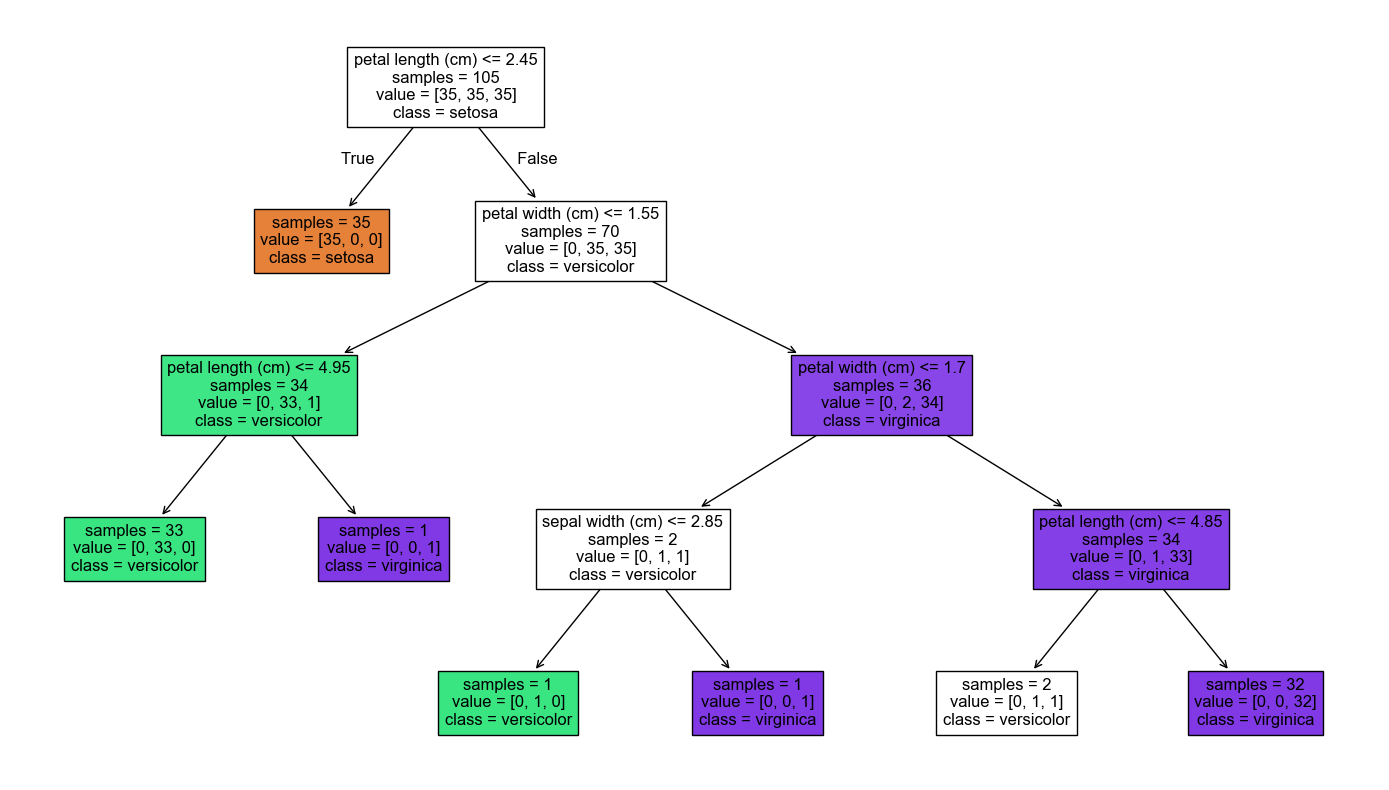

In [19]:
fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(
        model,
        feature_names=iris.feature_names,
        class_names=iris.target_names,
        filled=True,
        impurity=False,
        ax=ax,
    )
fig.tight_layout()

Podemos também visualizar uma estrutura em forma de árvore textual utilizando a função `export_text`:

In [27]:
print(
    export_text(
        model, 
        feature_names=list(iris.feature_names),
        class_names=iris.target_names
    )
)

|--- petal length (cm) <= 2.45
|   |--- class: setosa
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- class: versicolor
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- class: virginica
|   |--- petal width (cm) >  1.55
|   |   |--- petal width (cm) <= 1.70
|   |   |   |--- sepal width (cm) <= 2.85
|   |   |   |   |--- class: versicolor
|   |   |   |--- sepal width (cm) >  2.85
|   |   |   |   |--- class: virginica
|   |   |--- petal width (cm) >  1.70
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- class: versicolor
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: virginica



Calculando a acurácia de classificação:

In [20]:
y_pred = model.predict(X_test)
print(f"Acurácia (teste):  {accuracy_score(y_test, y_pred):.4f}")

Acurácia (teste):  0.8889


Bem como a matriz de confusão:

In [21]:
print("\nMatriz de confusão (teste):")
print(confusion_matrix(y_test, y_pred))


Matriz de confusão (teste):
[[15  0  0]
 [ 0 12  3]
 [ 0  2 13]]
